In [2]:
# Core data handling
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression models for price prediction
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Clustering models for market segmentation
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

# Model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import silhouette_score

# Save and load trained models
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
import pandas as pd

df = pd.read_csv(
    r"c:\Users\ADMIN\Downloads\diamonds.csv"
)

print(df.shape)

(53940, 10)


In [4]:
#Data Understanding Section
# ==========================================
# 1)Dataset Shape
# ==========================================

print("Dataset Shape:")
print(df.shape)

print("\nNumber of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

# 2)Shows the first 5 rows of the dataset.
df.head()

# 3)Last Five Records
df.tail()

# 4)Random Sample
df.sample(5)

# 5)Dataset Information
df.info()

Dataset Shape:
(53940, 10)

Number of Rows : 53940
Number of Columns : 10
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.7 MB


In [5]:
import pandas as pd
import numpy as np

# Check original shape
print("Original shape:", df.shape)

# 1. Check missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# 2. Remove duplicate rows
df = df.drop_duplicates()
print("\nShape after removing duplicates:", df.shape)

# 3. Remove invalid diamond dimensions
# x, y, z represent length, width, and depth. They should not be 0.
df = df[(df["x"] > 0) & (df["y"] > 0) & (df["z"] > 0)]

print("Shape after removing invalid dimensions:", df.shape)

# 4. Check categorical column values
print("\nUnique values in cut:")
print(df["cut"].unique())

print("\nUnique values in color:")
print(df["color"].unique())

print("\nUnique values in clarity:")
print(df["clarity"].unique())

# 5. Remove extreme outliers using IQR method
numeric_columns = ["carat", "depth", "table", "price", "x", "y", "z"]

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

print("\nShape after removing outliers:", df.shape)

# 6. Reset index after cleaning
df = df.reset_index(drop=True)

# 7. Final missing value check
print("\nMissing values after cleaning:")
print(df.isnull().sum())

# 8. Final cleaned data preview
print("\nCleaned dataset preview:")
print(df.head())

# Optional: Save cleaned dataset
df.to_csv("cleaned_diamonds.csv", index=False)

print("\nCleaned dataset saved as cleaned_diamonds.csv")

Original shape: (53940, 10)

Missing values before cleaning:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Shape after removing duplicates: (53794, 10)
Shape after removing invalid dimensions: (53775, 10)

Unique values in cut:
<ArrowStringArray>
['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Length: 5, dtype: str

Unique values in color:
<ArrowStringArray>
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Length: 7, dtype: str

Unique values in clarity:
<ArrowStringArray>
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Length: 8, dtype: str

Shape after removing outliers: (46425, 10)

Missing values after cleaning:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Cleaned dataset preview:
   carat        cut color clarity  depth  table  price     x     y     z
0   0.23      Ideal     E     SI2   61

In [6]:
## Invalid value treatment
df = df[(df["x"] > 0) & (df["y"] > 0) & (df["z"] > 0)]

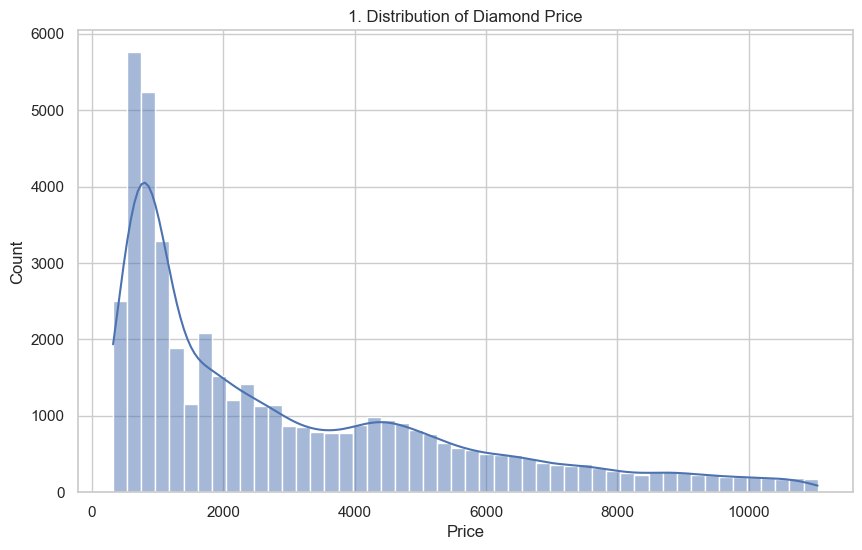

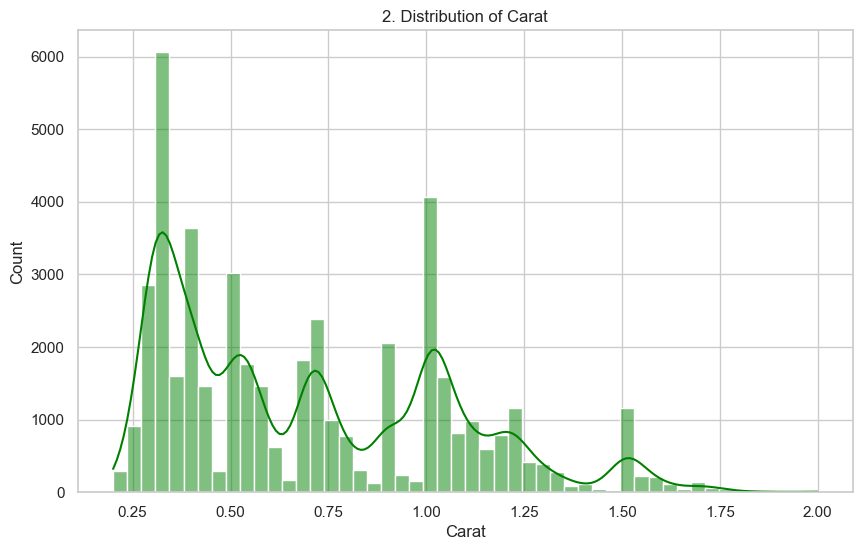

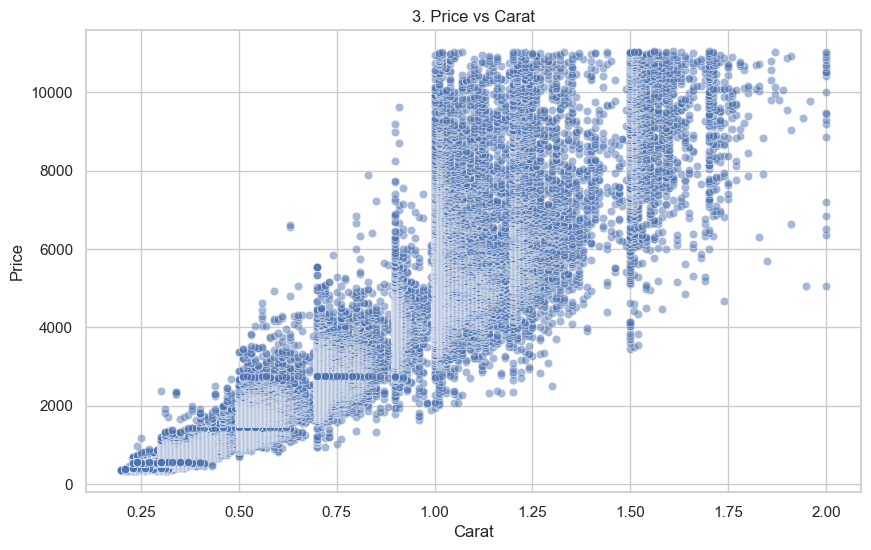

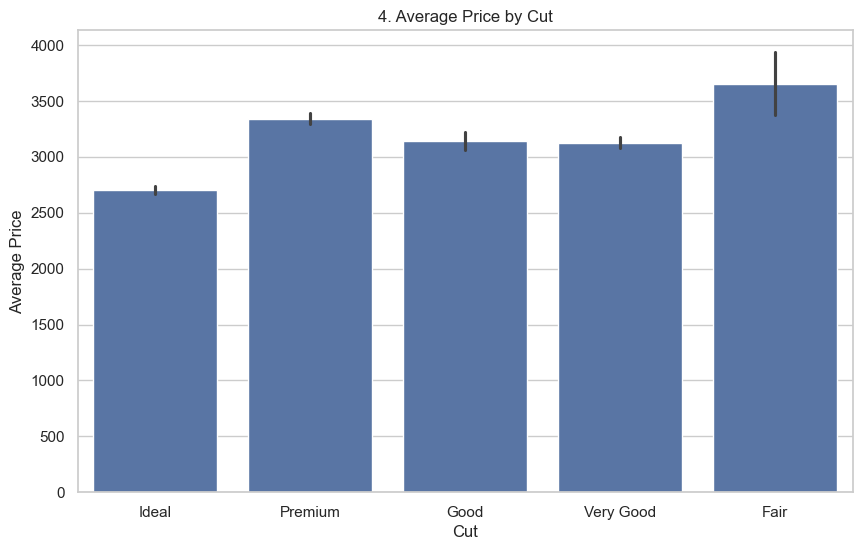

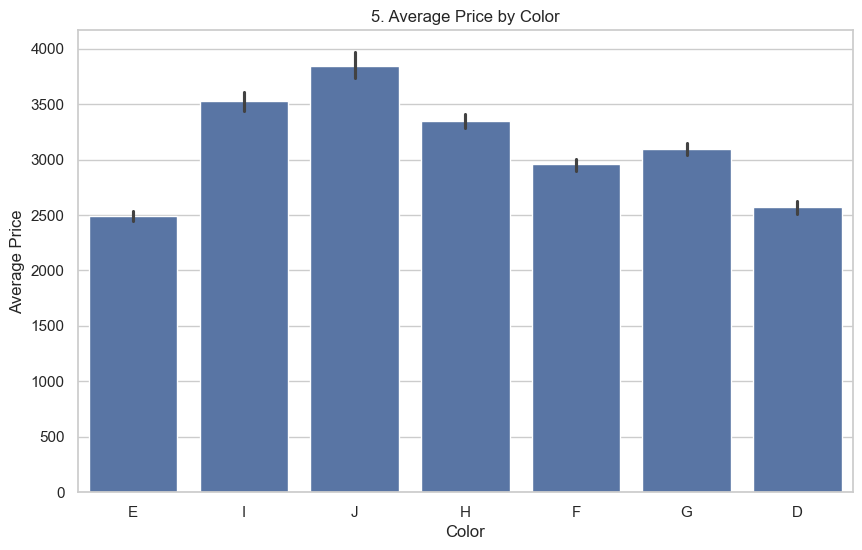

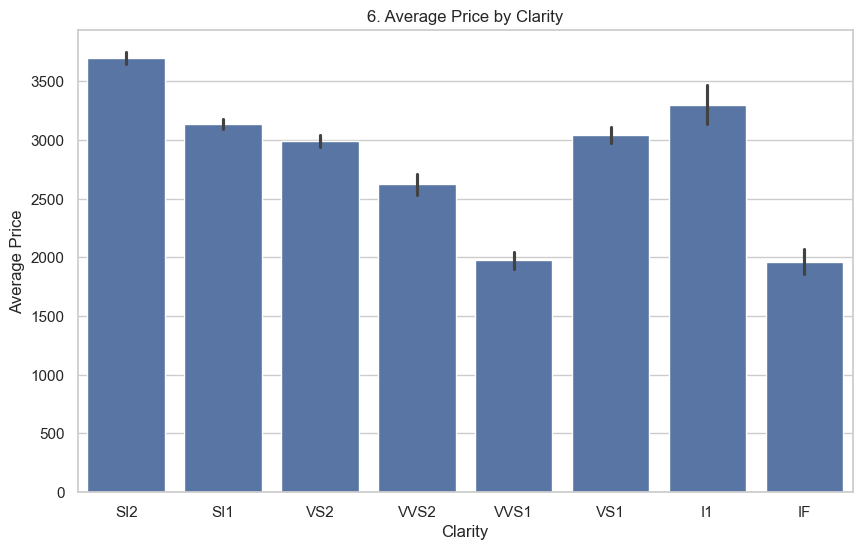

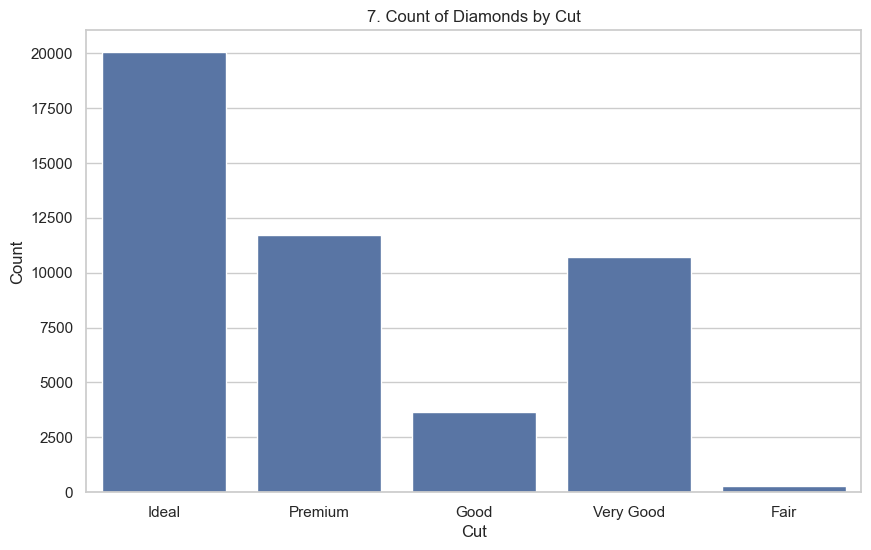

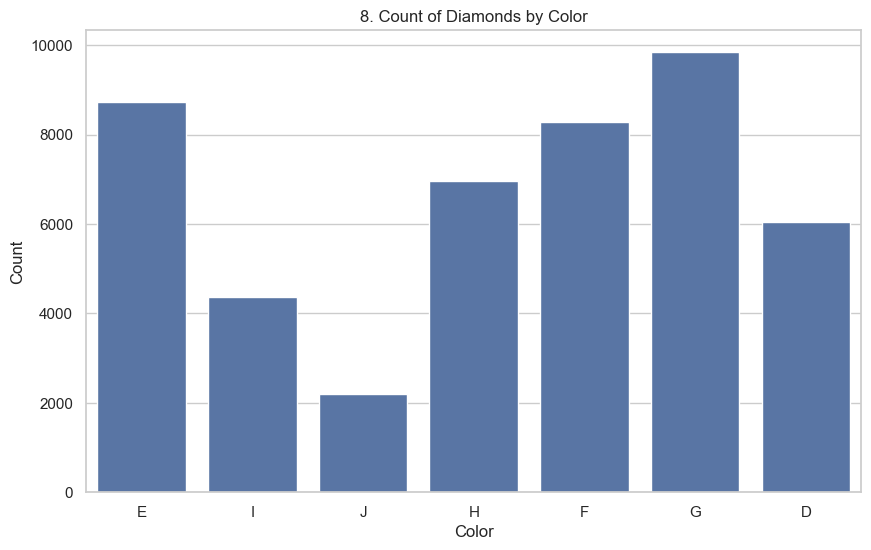

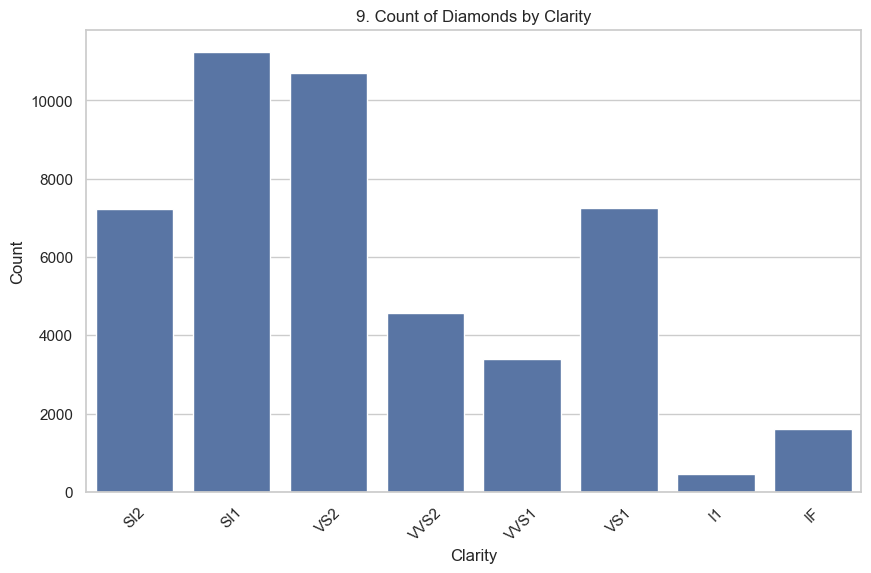

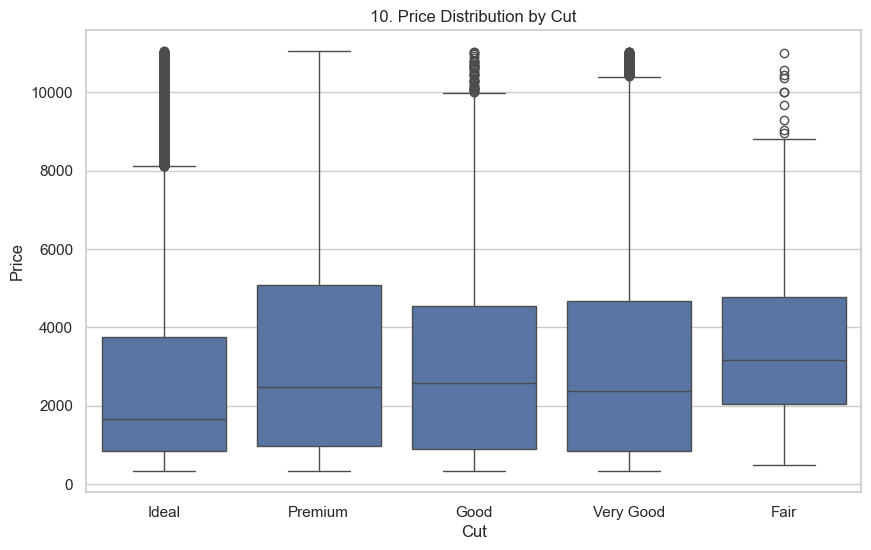

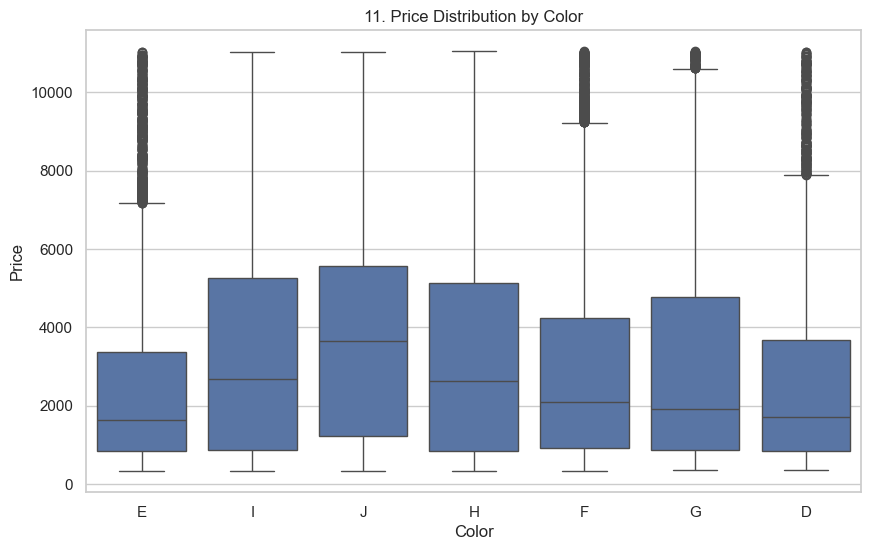

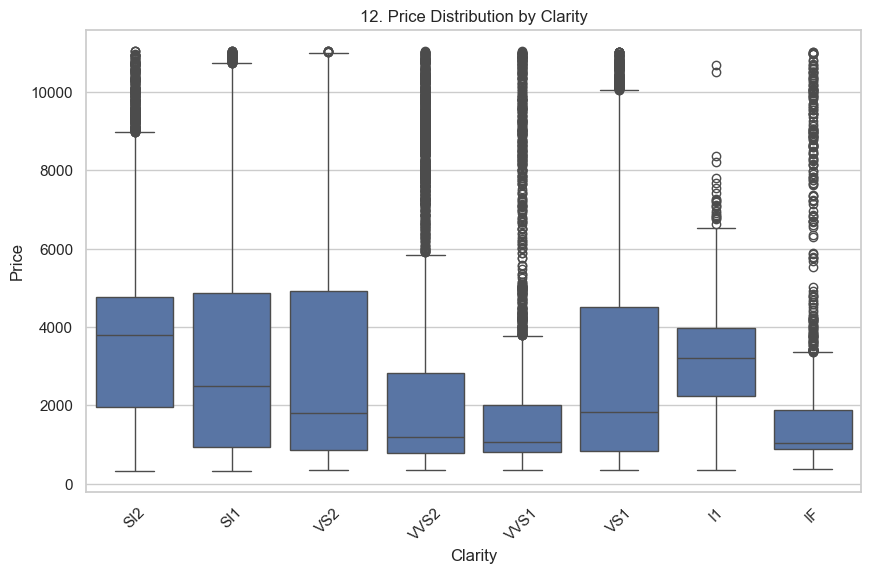

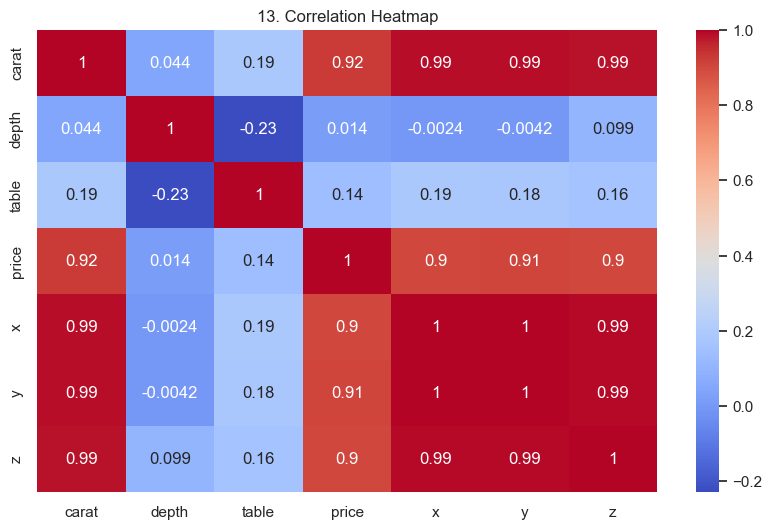

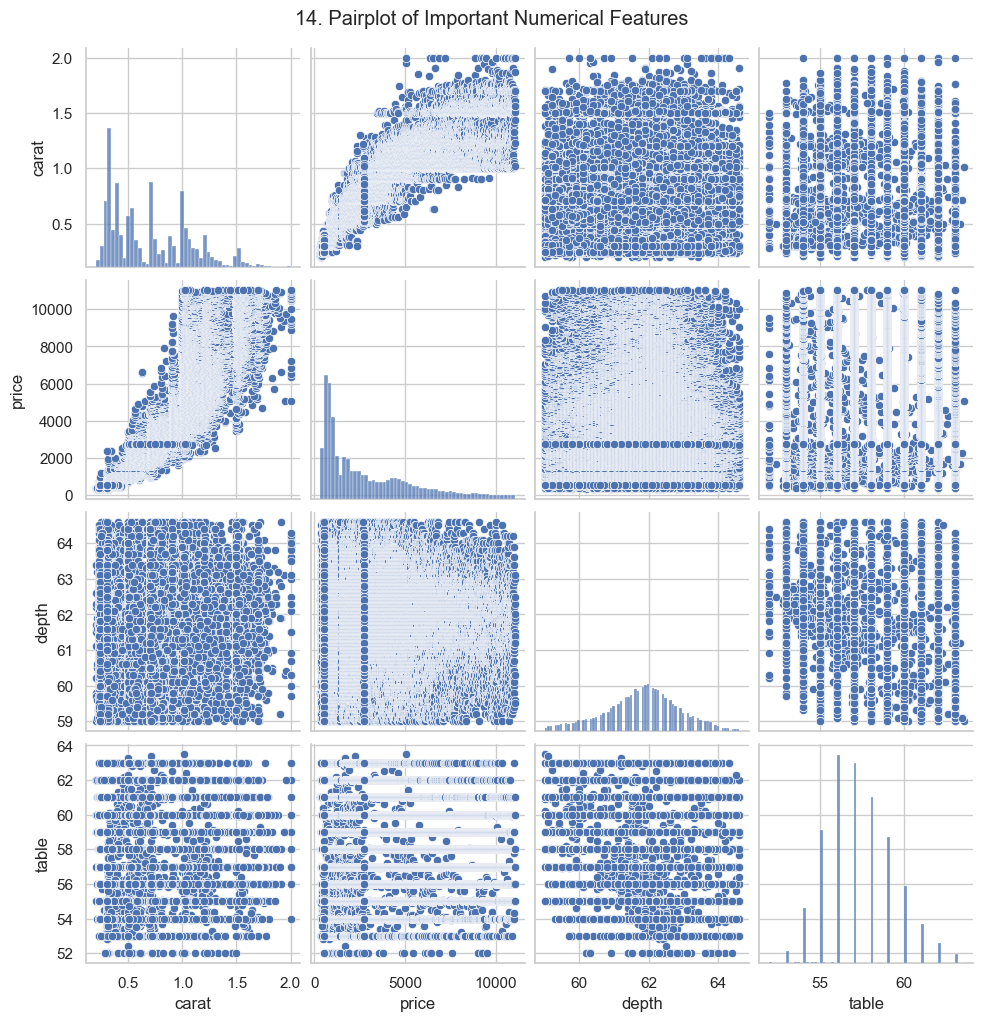

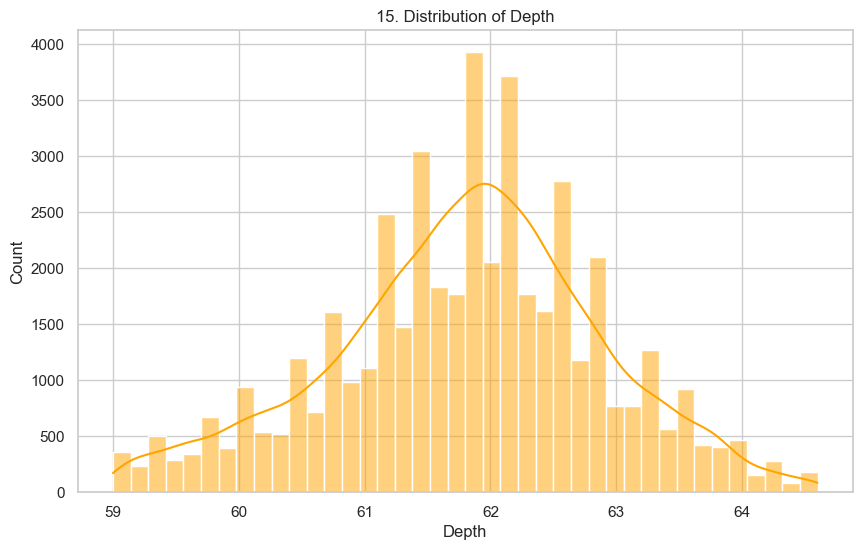

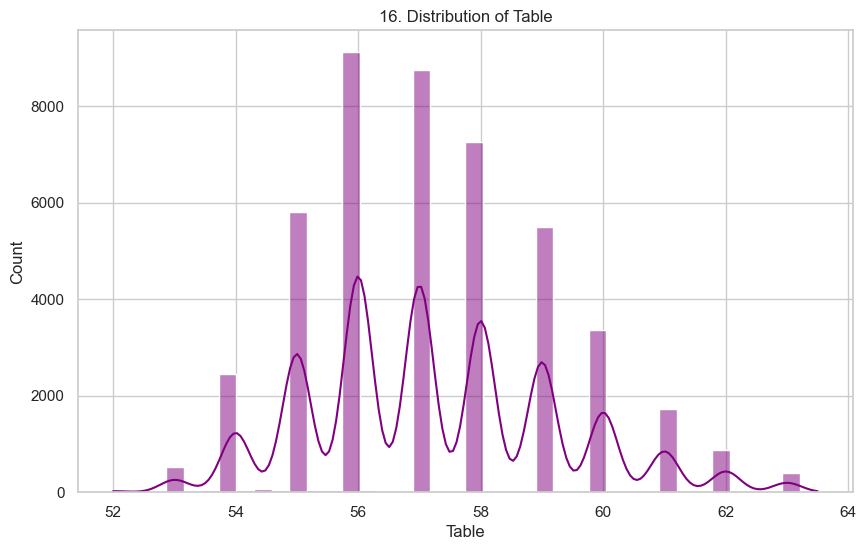

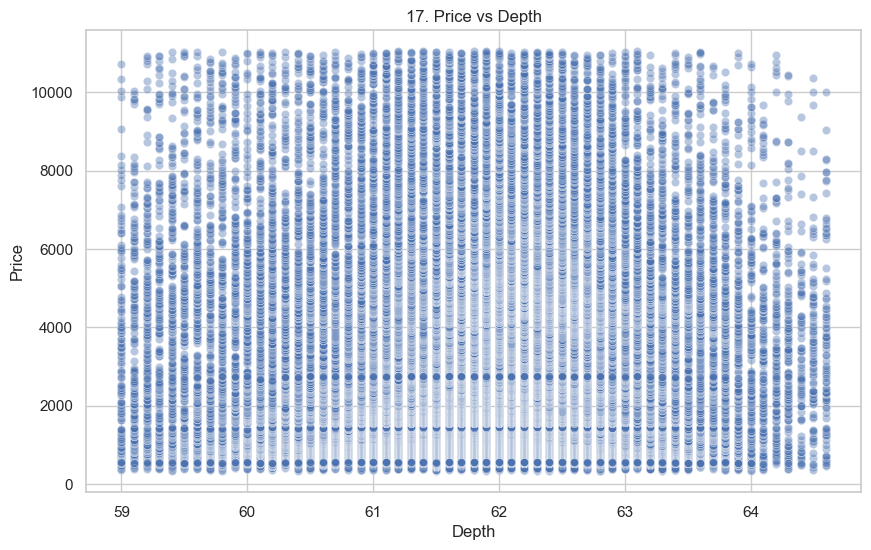

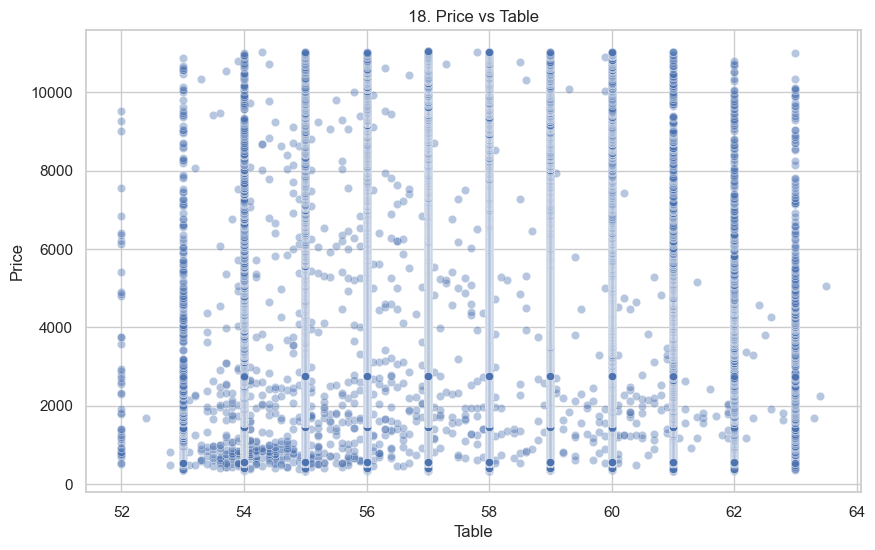

In [7]:
## EDA PROCESS
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("cleaned_diamonds.csv")

# Set plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. Price Distribution
sns.histplot(df["price"], bins=50, kde=True)
plt.title("1. Distribution of Diamond Price")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

# 2. Carat Distribution
sns.histplot(df["carat"], bins=50, kde=True, color="green")
plt.title("2. Distribution of Carat")
plt.xlabel("Carat")
plt.ylabel("Count")
plt.show()

# 3. Price vs Carat
sns.scatterplot(data=df, x="carat", y="price", alpha=0.5)
plt.title("3. Price vs Carat")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.show()

# 4. Average Price by Cut
sns.barplot(data=df, x="cut", y="price", estimator="mean")
plt.title("4. Average Price by Cut")
plt.xlabel("Cut")
plt.ylabel("Average Price")
plt.show()

# 5. Average Price by Color
sns.barplot(data=df, x="color", y="price", estimator="mean")
plt.title("5. Average Price by Color")
plt.xlabel("Color")
plt.ylabel("Average Price")
plt.show()

# 6. Average Price by Clarity
sns.barplot(data=df, x="clarity", y="price", estimator="mean")
plt.title("6. Average Price by Clarity")
plt.xlabel("Clarity")
plt.ylabel("Average Price")
plt.show()

# 7. Count of Diamonds by Cut
sns.countplot(data=df, x="cut")
plt.title("7. Count of Diamonds by Cut")
plt.xlabel("Cut")
plt.ylabel("Count")
plt.show()

# 8. Count of Diamonds by Color
sns.countplot(data=df, x="color")
plt.title("8. Count of Diamonds by Color")
plt.xlabel("Color")
plt.ylabel("Count")
plt.show()

# 9. Count of Diamonds by Clarity
sns.countplot(data=df, x="clarity")
plt.title("9. Count of Diamonds by Clarity")
plt.xlabel("Clarity")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# 10. Price Boxplot by Cut
sns.boxplot(data=df, x="cut", y="price")
plt.title("10. Price Distribution by Cut")
plt.xlabel("Cut")
plt.ylabel("Price")
plt.show()

# 11. Price Boxplot by Color
sns.boxplot(data=df, x="color", y="price")
plt.title("11. Price Distribution by Color")
plt.xlabel("Color")
plt.ylabel("Price")
plt.show()

# 12. Price Boxplot by Clarity
sns.boxplot(data=df, x="clarity", y="price")
plt.title("12. Price Distribution by Clarity")
plt.xlabel("Clarity")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

# 13. Correlation Heatmap
numeric_cols = ["carat", "depth", "table", "price", "x", "y", "z"]
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("13. Correlation Heatmap")
plt.show()

# 14. Pairplot of Important Numerical Features
sns.pairplot(df[["carat", "price", "depth", "table"]])
plt.suptitle("14. Pairplot of Important Numerical Features", y=1.02)
plt.show()

# 15. Depth Distribution
sns.histplot(df["depth"], bins=40, kde=True, color="orange")
plt.title("15. Distribution of Depth")
plt.xlabel("Depth")
plt.ylabel("Count")
plt.show()

# 16. Table Distribution
sns.histplot(df["table"], bins=40, kde=True, color="purple")
plt.title("16. Distribution of Table")
plt.xlabel("Table")
plt.ylabel("Count")
plt.show()

# 17. Price vs Depth
sns.scatterplot(data=df, x="depth", y="price", alpha=0.4)
plt.title("17. Price vs Depth")
plt.xlabel("Depth")
plt.ylabel("Price")
plt.show()

# 18. Price vs Table
sns.scatterplot(data=df, x="table", y="price", alpha=0.4)
plt.title("18. Price vs Table")
plt.xlabel("Table")
plt.ylabel("Price")
plt.show()

Shape before outlier handling: (53940, 10)

Column: carat
Lower Limit: -0.5599999999999999
Upper Limit: 2.0
Rows remaining: 52051

Column: depth
Lower Limit: 59.0
Upper Limit: 64.6
Rows remaining: 49255

Column: table
Lower Limit: 51.5
Upper Limit: 63.5
Rows remaining: 48913

Column: price
Lower Limit: -5174.0
Upper Limit: 11042.0
Rows remaining: 46545

Column: x
Lower Limit: 1.9650000000000007
Upper Limit: 9.044999999999998
Rows remaining: 46541

Column: y
Lower Limit: 1.9900000000000002
Upper Limit: 9.03
Rows remaining: 46540

Column: z
Lower Limit: 1.1850000000000003
Upper Limit: 5.625
Rows remaining: 46532

Shape after outlier handling: (46532, 10)


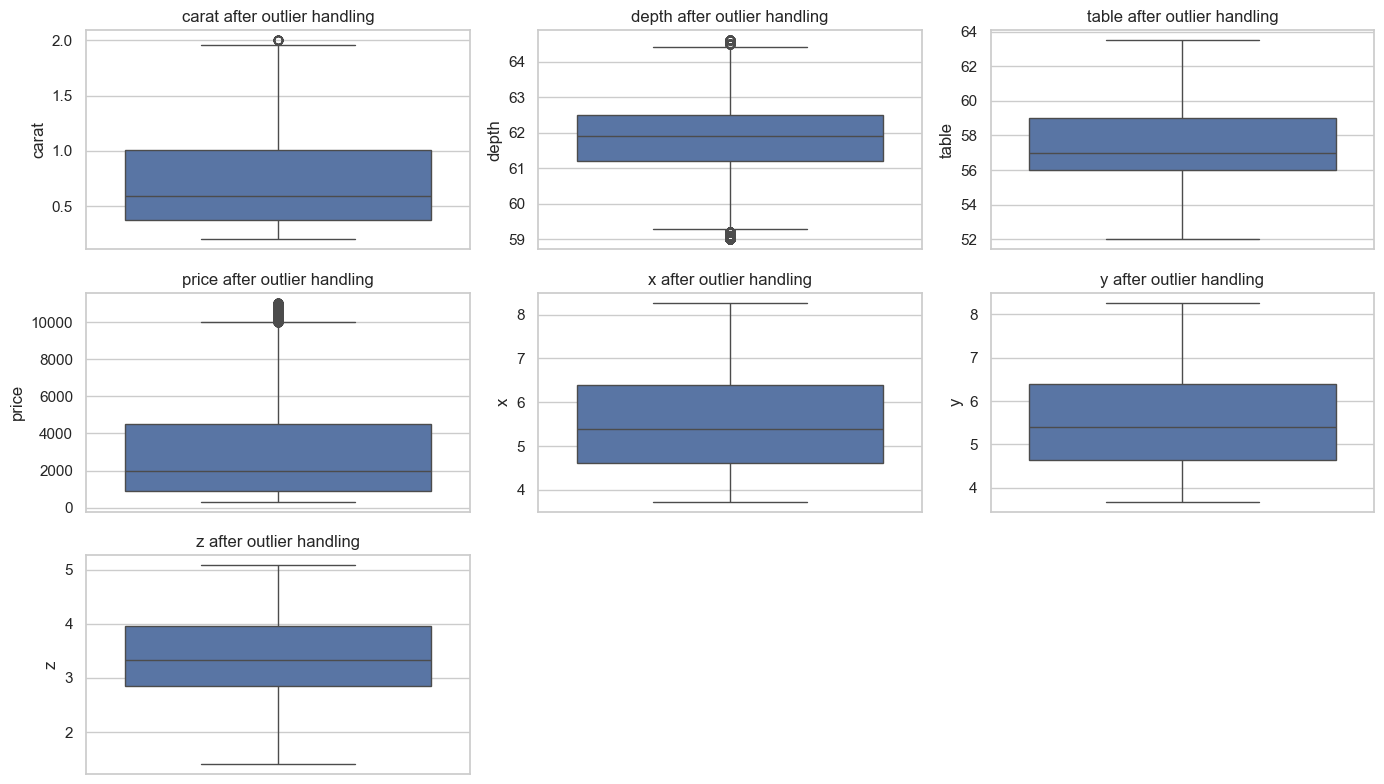


Outlier handled dataset saved as diamonds_no_outliers.csv


In [8]:
## OUTLIER HANDLING
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(
    r"c:\Users\ADMIN\Downloads\diamonds.csv"
)

print("Shape before outlier handling:", df.shape)

# Numerical columns for outlier handling
numeric_columns = ["carat", "depth", "table", "price", "x", "y", "z"]

# Function for outlier handling using IQR method
def remove_outliers_iqr(data, columns):
    cleaned_data = data.copy()

    for col in columns:
        Q1 = cleaned_data[col].quantile(0.25)
        Q3 = cleaned_data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        cleaned_data = cleaned_data[
            (cleaned_data[col] >= lower_limit) &
            (cleaned_data[col] <= upper_limit)
        ]

        print(f"\nColumn: {col}")
        print("Lower Limit:", lower_limit)
        print("Upper Limit:", upper_limit)
        print("Rows remaining:", cleaned_data.shape[0])

    return cleaned_data

# Apply outlier handling
df_no_outliers = remove_outliers_iqr(df, numeric_columns)

print("\nShape after outlier handling:", df_no_outliers.shape)

# Boxplots after outlier handling
plt.figure(figsize=(14, 8))

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_no_outliers[col])
    plt.title(f"{col} after outlier handling")

plt.tight_layout()
plt.show()

# Save the cleaned dataset
df_no_outliers.to_csv(
    r"c:\Users\ADMIN\Downloads\diamonds_no_outliers.csv",
    index=False
)

print("\nOutlier handled dataset saved as diamonds_no_outliers.csv")

Original Shape: (53940, 10)

Skewness before handling:
carat    1.116646
depth   -0.082294
table    0.796896
price    1.618395
x        0.378676
y        2.434167
z        1.522423
dtype: float64


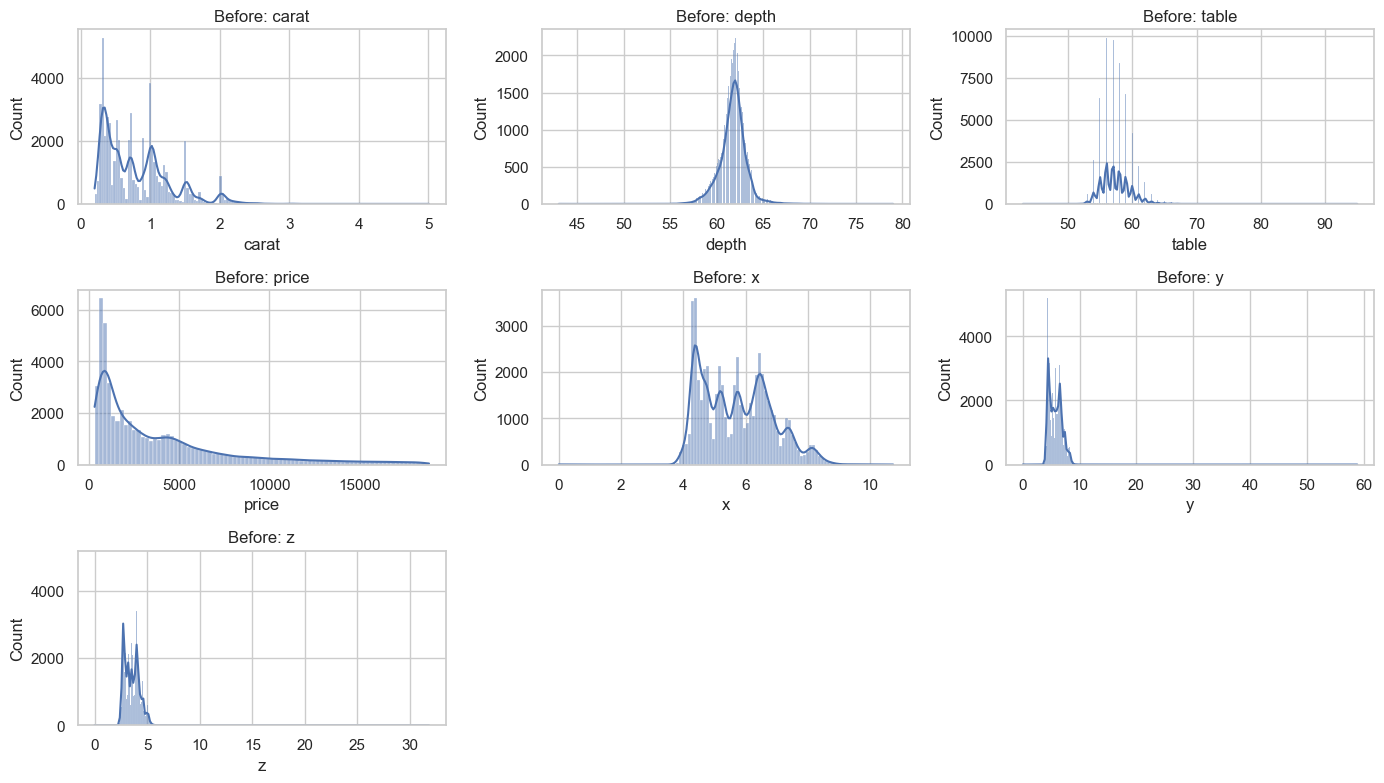


Skewness after handling:
carat    0.580654
depth   -0.082294
table    0.796896
price    0.115926
x       -0.073063
y        0.006600
z       -0.145424
dtype: float64


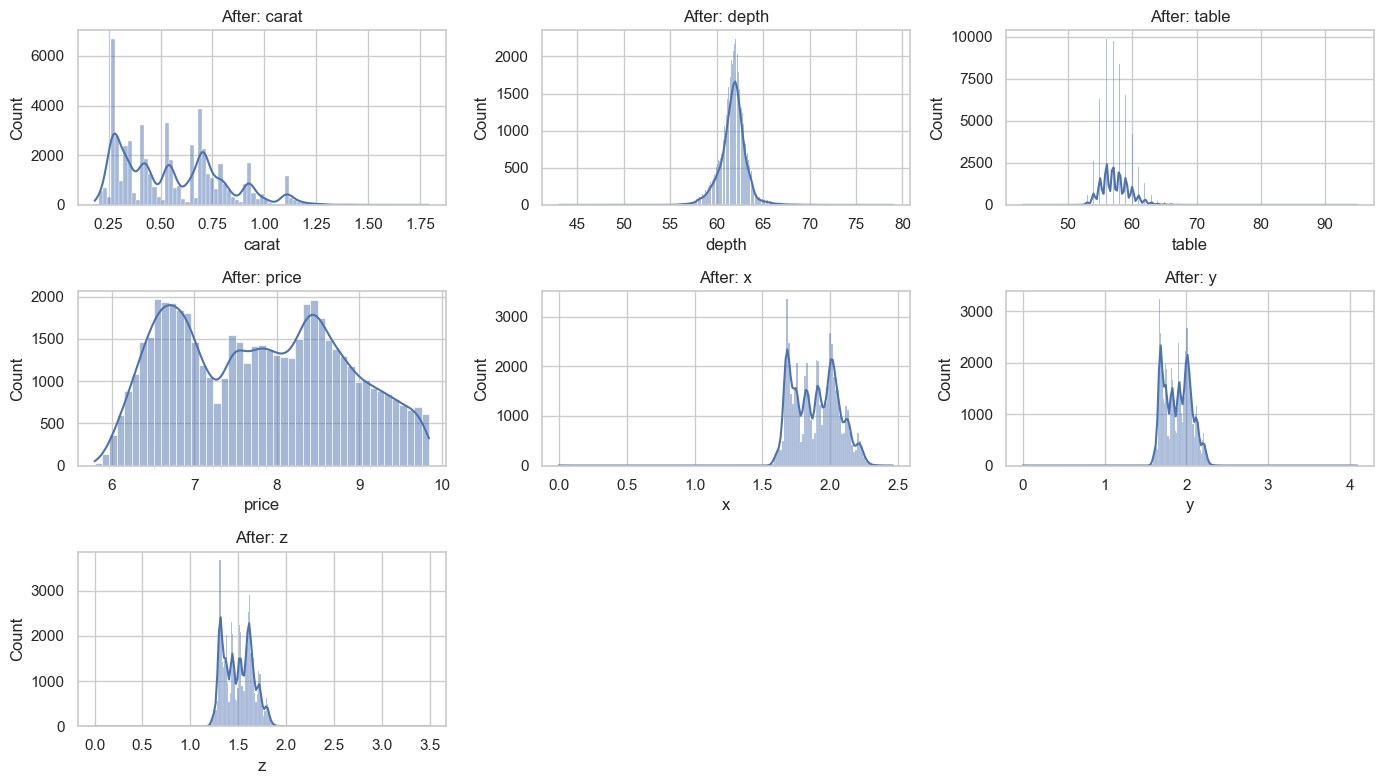


Skewness handled dataset saved as diamonds_skew_handled.csv


In [9]:
## SKEW HANDLING 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(
    r"c:\Users\ADMIN\Downloads\diamonds.csv"
)

print("Original Shape:", df.shape)

# Numerical columns to check skewness
numeric_columns = ["carat", "depth", "table", "price", "x", "y", "z"]

# Check skewness before transformation
print("\nSkewness before handling:")
print(df[numeric_columns].skew())

# Visualize skewness before transformation
plt.figure(figsize=(14, 8))

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Before: {col}")

plt.tight_layout()
plt.show()

# Create a copy for skewness handling
df_skew_handled = df.copy()

# Apply log1p transformation to positively skewed columns
# log1p means log(1 + value), safer when values include 0
skewed_columns = ["carat", "price", "x", "y", "z"]

for col in skewed_columns:
    df_skew_handled[col] = np.log1p(df_skew_handled[col])

# Check skewness after transformation
print("\nSkewness after handling:")
print(df_skew_handled[numeric_columns].skew())

# Visualize skewness after transformation
plt.figure(figsize=(14, 8))

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df_skew_handled[col], kde=True)
    plt.title(f"After: {col}")

plt.tight_layout()
plt.show()

# Save skewness handled dataset
df_skew_handled.to_csv(
    r"c:\Users\ADMIN\Downloads\diamonds_skew_handled.csv",
    index=False
)

print("\nSkewness handled dataset saved as diamonds_skew_handled.csv")

In [10]:
## FEATURE ENGINEERING
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv(
    r"c:\Users\ADMIN\Downloads\diamonds.csv"
)

print("Shape before feature engineering:", df.shape)

# 1. Create volume feature
# x, y, z represent diamond length, width, and depth
df["volume"] = df["x"] * df["y"] * df["z"]

# 2. Create price per carat feature
df["price_per_carat"] = df["price"] / df["carat"]

# 3. Create size category based on carat
def carat_category(carat):
    if carat < 0.5:
        return "Small"
    elif carat < 1.0:
        return "Medium"
    elif carat < 2.0:
        return "Large"
    else:
        return "Very Large"

df["carat_category"] = df["carat"].apply(carat_category)

# 4. Create price category for market segmentation
def price_category(price):
    if price < 1000:
        return "Budget"
    elif price < 5000:
        return "Mid Range"
    elif price < 10000:
        return "Premium"
    else:
        return "Luxury"

df["price_category"] = df["price"].apply(price_category)

# 5. Create quality score from cut, color, and clarity

cut_map = {
    "Fair": 1,
    "Good": 2,
    "Very Good": 3,
    "Premium": 4,
    "Ideal": 5
}

color_map = {
    "J": 1,
    "I": 2,
    "H": 3,
    "G": 4,
    "F": 5,
    "E": 6,
    "D": 7
}

clarity_map = {
    "I1": 1,
    "SI2": 2,
    "SI1": 3,
    "VS2": 4,
    "VS1": 5,
    "VVS2": 6,
    "VVS1": 7,
    "IF": 8
}

df["cut_score"] = df["cut"].map(cut_map)
df["color_score"] = df["color"].map(color_map)
df["clarity_score"] = df["clarity"].map(clarity_map)

df["quality_score"] = (
    df["cut_score"] +
    df["color_score"] +
    df["clarity_score"]
)

# 6. Create depth-to-table ratio
df["depth_table_ratio"] = df["depth"] / df["table"]

# 7. Replace infinite values if any
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 8. Drop missing values created during feature engineering
df.dropna(inplace=True)

# 9. Display new columns
print("\nNew columns created:")
print([
    "volume",
    "price_per_carat",
    "carat_category",
    "price_category",
    "cut_score",
    "color_score",
    "clarity_score",
    "quality_score",
    "depth_table_ratio"
])

print("\nDataset preview after feature engineering:")
print(df.head())

print("\nShape after feature engineering:", df.shape)

# Save feature engineered dataset
df.to_csv(
    r"c:\Users\ADMIN\Downloads\diamonds_feature_engineered.csv",
    index=False
)

print("\nFeature engineered dataset saved as diamonds_feature_engineered.csv")

Shape before feature engineering: (53940, 10)

New columns created:
['volume', 'price_per_carat', 'carat_category', 'price_category', 'cut_score', 'color_score', 'clarity_score', 'quality_score', 'depth_table_ratio']

Dataset preview after feature engineering:
   carat      cut color clarity  depth  table  price     x     y     z  \
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43   
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31   
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31   
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63   
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75   

      volume  price_per_carat carat_category price_category  cut_score  \
0  38.202030      1417.391304          Small         Budget          5   
1  34.505856      1552.380952          Small         Budget          4   
2  38.076885      1421.739130          Small         Budget          2  

Dataset shape: (53940, 19)

Encoded dataset preview:
   carat  cut  color  clarity  depth  table  price     x     y     z  \
0   0.23    2      1        3   61.5   55.0    326  3.95  3.98  2.43   
1   0.21    3      1        2   59.8   61.0    326  3.89  3.84  2.31   
2   0.23    1      1        4   56.9   65.0    327  4.05  4.07  2.31   
3   0.29    3      5        5   62.4   58.0    334  4.20  4.23  2.63   
4   0.31    1      6        3   63.3   58.0    335  4.34  4.35  2.75   

      volume  price_per_carat  carat_category  price_category  cut_score  \
0  38.202030      1417.391304               2               0          5   
1  34.505856      1552.380952               2               0          4   
2  38.076885      1421.739130               2               0          2   
3  46.724580      1151.724138               2               0          4   
4  51.917250      1080.645161               2               0          2   

   color_score  clarity_score  quality_score  depth_table

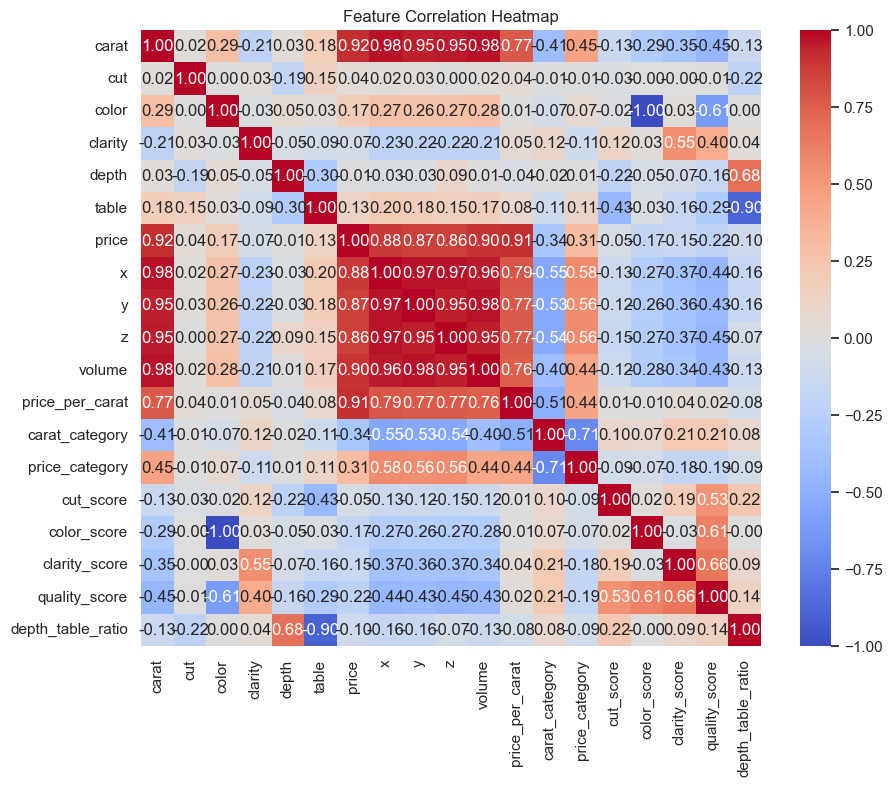


Top features selected by SelectKBest:
['carat', 'color', 'x', 'y', 'z', 'volume', 'price_per_carat', 'carat_category', 'price_category', 'quality_score']

SelectKBest feature scores:
              Feature          Score
0               carat  304050.905940
10    price_per_carat  267949.576093
9              volume  236516.366823
6                   x  193740.279069
7                   y  160914.481807
8                   z  154922.121057
11     carat_category    7078.842907
12     price_category    5758.063253
16      quality_score    2678.141398
2               color    1654.431904
14        color_score    1654.431904
15      clarity_score    1187.979233
5               table     886.123908
17  depth_table_ratio     597.598713
3             clarity     277.434034
13          cut_score     154.772990
1                 cut      85.835381
4               depth       6.115495


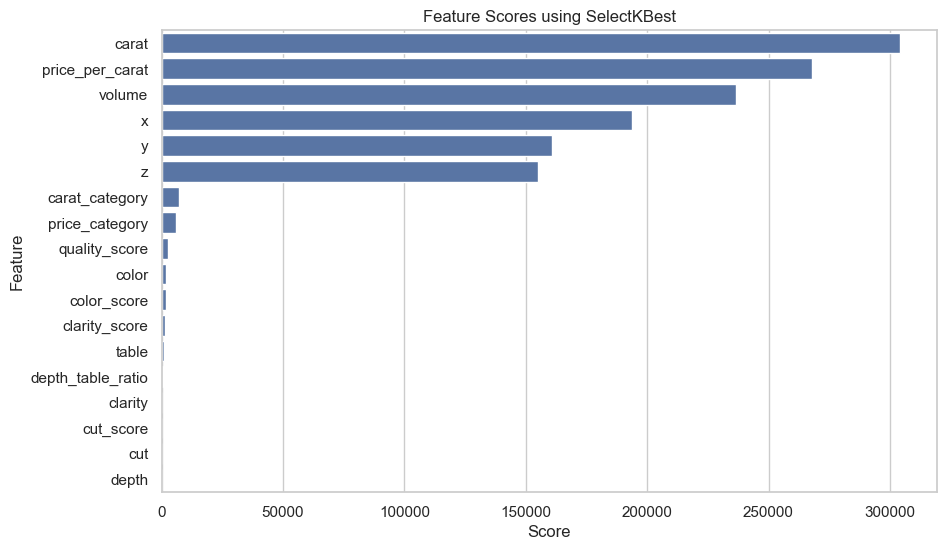


Feature importance from Random Forest:
              Feature  Importance
10    price_per_carat    0.683525
12     price_category    0.142293
0               carat    0.079084
9              volume    0.071580
7                   y    0.018372
6                   x    0.003756
8                   z    0.001207
11     carat_category    0.000035
4               depth    0.000029
17  depth_table_ratio    0.000026
16      quality_score    0.000019
5               table    0.000016
1                 cut    0.000011
15      clarity_score    0.000011
2               color    0.000011
14        color_score    0.000010
3             clarity    0.000008
13          cut_score    0.000008


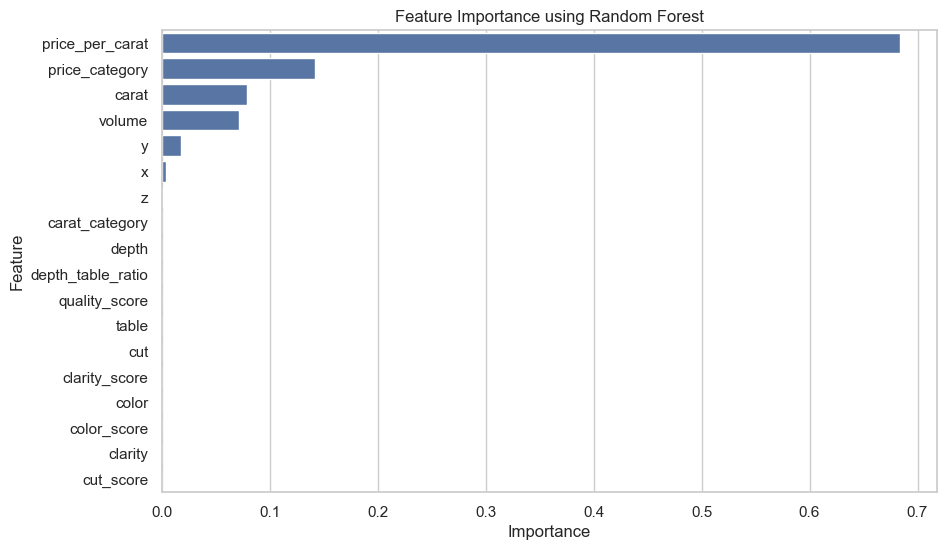


Final selected features for model building:
['price_per_carat', 'price_category', 'carat', 'volume', 'y', 'x', 'z', 'carat_category', 'depth', 'depth_table_ratio']

Final selected dataset preview:
   price_per_carat  price_category  carat     volume     y     x     z  \
0      1417.391304               0   0.23  38.202030  3.98  3.95  2.43   
1      1552.380952               0   0.21  34.505856  3.84  3.89  2.31   
2      1421.739130               0   0.23  38.076885  4.07  4.05  2.31   
3      1151.724138               0   0.29  46.724580  4.23  4.20  2.63   
4      1080.645161               0   0.31  51.917250  4.35  4.34  2.75   

   carat_category  depth  depth_table_ratio  price  
0               2   61.5           1.118182    326  
1               2   59.8           0.980328    326  
2               2   56.9           0.875385    327  
3               2   62.4           1.075862    334  
4               2   63.3           1.091379    335  

Selected feature dataset saved as diam

In [11]:
## FEATURE SELECTION
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split

# Load feature engineered dataset
df = pd.read_csv(
    r"c:\Users\ADMIN\Downloads\diamonds_feature_engineered.csv"
)

print("Dataset shape:", df.shape)

# -------------------------------
# 1. Encode categorical columns
# -------------------------------

df_encoded = df.copy()

categorical_columns = [
    "cut",
    "color",
    "clarity",
    "carat_category",
    "price_category"
]

label_encoder = LabelEncoder()

for col in categorical_columns:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

print("\nEncoded dataset preview:")
print(df_encoded.head())

# -------------------------------
# 2. Define features and target
# -------------------------------

X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget column: price")

# -------------------------------
# 3. Correlation with target
# -------------------------------

correlation = df_encoded.corr(numeric_only=True)["price"].sort_values(ascending=False)

print("\nCorrelation with price:")
print(correlation)

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_encoded.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Feature Correlation Heatmap")
plt.show()

# -------------------------------
# 4. SelectKBest feature selection
# -------------------------------

selector = SelectKBest(score_func=f_regression, k=10)
X_selected = selector.fit_transform(X, y)

selected_features_kbest = X.columns[selector.get_support()]

print("\nTop features selected by SelectKBest:")
print(selected_features_kbest.tolist())

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
}).sort_values(by="Score", ascending=False)

print("\nSelectKBest feature scores:")
print(feature_scores)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_scores, x="Score", y="Feature")
plt.title("Feature Scores using SelectKBest")
plt.show()

# -------------------------------
# 5. Random Forest feature importance
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature importance from Random Forest:")
print(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importance using Random Forest")
plt.show()

# -------------------------------
# 6. Final selected features
# -------------------------------

final_selected_features = importance_df.head(10)["Feature"].tolist()

print("\nFinal selected features for model building:")
print(final_selected_features)

# Create final dataset with selected features and target
df_selected = df_encoded[final_selected_features + ["price"]]

print("\nFinal selected dataset preview:")
print(df_selected.head())

# Save selected feature dataset
df_selected.to_csv(
    r"c:\Users\ADMIN\Downloads\diamonds_selected_features.csv",
    index=False
)

print("\nSelected feature dataset saved as diamonds_selected_features.csv")

In [13]:
## ENCODING 
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv(
    r"c:\Users\ADMIN\Downloads\diamonds_feature_engineered.csv"
)

print("Shape before encoding:", df.shape)

# Check categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("\nCategorical columns:")
print(categorical_columns.tolist())

# Create copy for encoding
df_encoded = df.copy()

# Ordinal encoding based on diamond quality order

cut_order = {
    "Fair": 1,
    "Good": 2,
    "Very Good": 3,
    "Premium": 4,
    "Ideal": 5
}

color_order = {
    "J": 1,
    "I": 2,
    "H": 3,
    "G": 4,
    "F": 5,
    "E": 6,
    "D": 7
}

clarity_order = {
    "I1": 1,
    "SI2": 2,
    "SI1": 3,
    "VS2": 4,
    "VS1": 5,
    "VVS2": 6,
    "VVS1": 7,
    "IF": 8
}

carat_category_order = {
    "Small": 1,
    "Medium": 2,
    "Large": 3,
    "Very Large": 4
}

price_category_order = {
    "Budget": 1,
    "Mid Range": 2,
    "Premium": 3,
    "Luxury": 4
}

# Apply ordinal encoding
df_encoded["cut_encoded"] = df_encoded["cut"].map(cut_order)
df_encoded["color_encoded"] = df_encoded["color"].map(color_order)
df_encoded["clarity_encoded"] = df_encoded["clarity"].map(clarity_order)
df_encoded["carat_category_encoded"] = df_encoded["carat_category"].map(carat_category_order)
df_encoded["price_category_encoded"] = df_encoded["price_category"].map(price_category_order)

# Drop original categorical columns after encoding
df_encoded = df_encoded.drop(
    ["cut", "color", "clarity", "carat_category", "price_category"],
    axis=1
)

# Check missing values after encoding
print("\nMissing values after encoding:")
print(df_encoded.isnull().sum())

# Preview encoded data
print("\nEncoded dataset preview:")
print(df_encoded.head())

print("\nShape after encoding:", df_encoded.shape)

# Save encoded dataset
df_encoded.to_csv(
    r"c:\Users\ADMIN\Downloads\diamonds_encoded.csv",
    index=False
)

print("\nEncoded dataset saved as diamonds_encoded.csv")

Shape before encoding: (53940, 19)

Categorical columns:
['cut', 'color', 'clarity', 'carat_category', 'price_category']

Missing values after encoding:
carat                     0
depth                     0
table                     0
price                     0
x                         0
y                         0
z                         0
volume                    0
price_per_carat           0
cut_score                 0
color_score               0
clarity_score             0
quality_score             0
depth_table_ratio         0
cut_encoded               0
color_encoded             0
clarity_encoded           0
carat_category_encoded    0
price_category_encoded    0
dtype: int64

Encoded dataset preview:
   carat  depth  table  price     x     y     z     volume  price_per_carat  \
0   0.23   61.5   55.0    326  3.95  3.98  2.43  38.202030      1417.391304   
1   0.21   59.8   61.0    326  3.89  3.84  2.31  34.505856      1552.380952   
2   0.23   56.9   65.0    327  4.05  4.

In [14]:
## SCALING 
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load encoded dataset
df = pd.read_csv(
    r"c:\Users\ADMIN\Downloads\diamonds_encoded.csv"
)

print("Shape before scaling:", df.shape)

# Separate features and target
X = df.drop("price", axis=1)
y = df["price"]

# Select numerical columns for scaling
numeric_columns = X.columns

# Apply StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X[numeric_columns])

# Convert scaled data back to DataFrame
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=numeric_columns
)

# Add target column back
df_scaled = pd.concat(
    [X_scaled_df, y.reset_index(drop=True)],
    axis=1
)

print("\nScaled dataset preview:")
print(df_scaled.head())

print("\nShape after scaling:", df_scaled.shape)

# Save scaled dataset
df_scaled.to_csv(
    r"c:\Users\ADMIN\Downloads\diamonds_scaled.csv",
    index=False
)

print("\nScaled dataset saved as diamonds_scaled.csv")

Shape before scaling: (53940, 19)

Scaled dataset preview:
      carat     depth     table         x         y         z    volume  \
0 -1.198168 -0.174092 -1.099672 -1.587837 -1.536196 -1.571129 -1.171294   
1 -1.240361 -1.360738  1.585529 -1.641325 -1.658774 -1.741175 -1.218533   
2 -1.198168 -3.385019  3.375663 -1.498691 -1.457395 -1.741175 -1.172894   
3 -1.071587  0.454133  0.242928 -1.364971 -1.317305 -1.287720 -1.062372   
4 -1.029394  1.082358  0.242928 -1.240167 -1.212238 -1.117674 -0.996008   

   price_per_carat  cut_score  color_score  clarity_score  quality_score  \
0        -1.287361   0.981473     0.937163      -1.245215       0.233614   
1        -1.220290   0.085889     0.937163      -0.638095       0.233614   
2        -1.285201  -1.705279     0.937163       0.576145       0.233614   
3        -1.419360   0.085889    -1.414272      -0.030975      -0.863028   
4        -1.454676  -1.705279    -2.002131      -1.245215      -2.690764   

   depth_table_ratio  cut_encoded

In [15]:
## REGRESSION MODELS 
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# XGBoost model
# Install if needed: pip install xgboost
from xgboost import XGBRegressor

# Load scaled dataset
df = pd.read_csv(
    r"c:\Users\ADMIN\Downloads\diamonds_scaled.csv"
)

print("Dataset shape:", df.shape)

# Separate input features and target
X = df.drop("price", axis=1)
y = df["price"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create 5 regression models
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "KNN Regressor": KNeighborsRegressor(
        n_neighbors=5
    ),

    "XGBoost Regressor": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        objective="reg:squarederror"
    )
}

# Train and evaluate models
results = []

for model_name, model in models.items():
    print("\nTraining model:", model_name)

    # Train model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

# Convert results into DataFrame
results_df = pd.DataFrame(results)

# Sort models by best R2 score
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print("\nModel Comparison Results:")
print(results_df)

# Best model
best_model = results_df.iloc[0]

print("\nBest Performing Model:")
print(best_model)

Dataset shape: (53940, 19)

Training model: Linear Regression

Training model: Decision Tree

Training model: Random Forest

Training model: KNN Regressor

Training model: XGBoost Regressor

Model Comparison Results:
               Model         MAE            MSE        RMSE  R2 Score
2      Random Forest   17.970115    4394.314499   66.289626  0.999724
1      Decision Tree   30.709677   14107.175751  118.773632  0.999113
4  XGBoost Regressor   63.892185   21055.041016  145.103553  0.998676
3      KNN Regressor  241.840044  183975.266162  428.923380  0.988427
0  Linear Regression  333.052493  284677.698699  533.551964  0.982092

Best Performing Model:
Model       Random Forest
MAE             17.970115
MSE           4394.314499
RMSE            66.289626
R2 Score         0.999724
Name: 2, dtype: object


In [16]:
## ANN MODEL
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load scaled dataset
df = pd.read_csv(
    r"c:\Users\ADMIN\Downloads\diamonds_scaled.csv"
)

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

ann_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42
)

ann_model.fit(X_train, y_train)

y_pred = ann_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("ANN Model using Scikit-learn")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

ANN Model using Scikit-learn
MAE: 28.680387985822687
MSE: 2098.7131954599904
RMSE: 45.811714609475054
R2 Score: 0.9998679790672685


Original dataset shape: (53940, 19)
Sample dataset shape: (10000, 19)


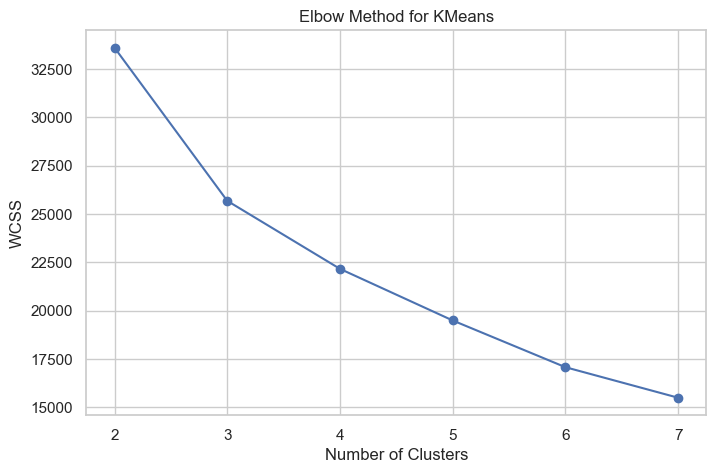

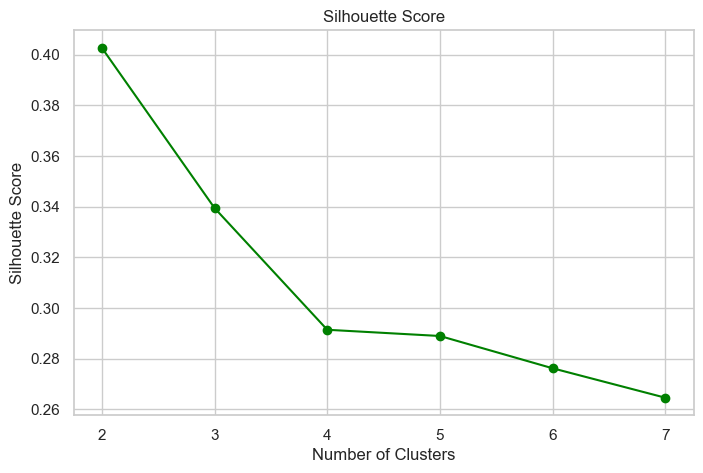


Cluster counts:
cluster
3    4125
2    2847
0    1703
1    1325
Name: count, dtype: int64


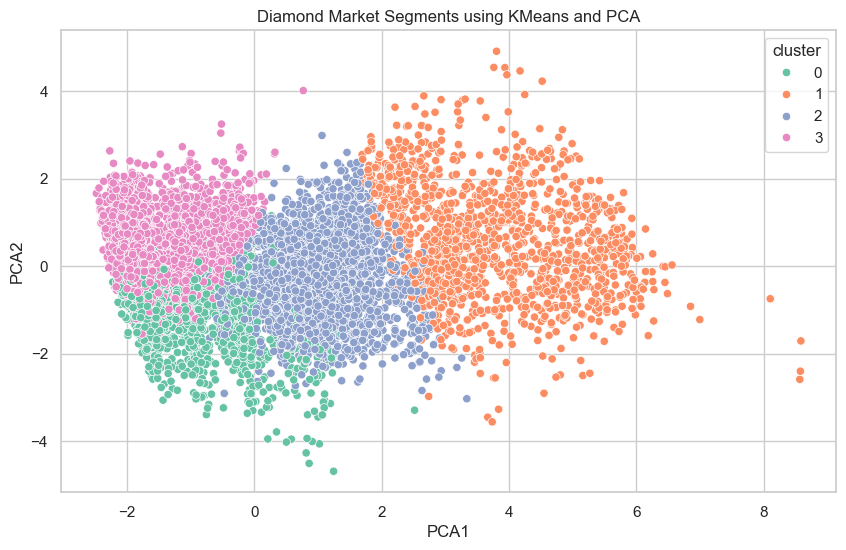


Cluster Profile:
            carat         price      volume  price_per_carat  quality_score  \
cluster                                                                       
0        0.538485   1605.270699   87.624420      2726.601794      11.637698   
1        1.658566  12412.446038  269.491599      7645.788676      11.675472   
2        1.058001   5019.749210  171.284931      4712.243511      10.656832   
3        0.443120   1341.108606   72.818357      2817.026996      14.018667   

         depth_table_ratio  
cluster                     
0                 1.013351  
1                 1.063129  
2                 1.080166  
3                 1.106029  

Clustered sample dataset saved as diamonds_clustered_sample.csv


In [18]:
## CLUSTERING MODELS
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load feature engineered dataset
df = pd.read_csv(
    r"c:\Users\ADMIN\Downloads\diamonds_feature_engineered.csv"
)

# Use sample for faster clustering
df_sample = df.sample(10000, random_state=42)

print("Original dataset shape:", df.shape)
print("Sample dataset shape:", df_sample.shape)

# Select features for clustering
clustering_features = [
    "carat",
    "price",
    "volume",
    "price_per_carat",
    "quality_score",
    "depth_table_ratio"
]

X = df_sample[clustering_features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
wcss = []

for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), wcss, marker="o")
plt.title("Elbow Method for KMeans")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Silhouette Score
silhouette_scores = []

for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), silhouette_scores, marker="o", color="green")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

# Apply final KMeans
best_k = 4

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df_sample["cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster counts:")
print(df_sample["cluster"].value_counts())

# PCA visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df_sample["PCA1"] = pca_result[:, 0]
df_sample["PCA2"] = pca_result[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_sample,
    x="PCA1",
    y="PCA2",
    hue="cluster",
    palette="Set2"
)
plt.title("Diamond Market Segments using KMeans and PCA")
plt.show()

# Cluster profiling
cluster_profile = df_sample.groupby("cluster")[clustering_features].mean()

print("\nCluster Profile:")
print(cluster_profile)

# Save clustered sample dataset
df_sample.to_csv(
    r"c:\Users\ADMIN\Downloads\diamonds_clustered_sample.csv",
    index=False
)

print("\nClustered sample dataset saved as diamonds_clustered_sample.csv")

In [19]:
## CLUSTER NAMING 
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load feature engineered dataset
df = pd.read_csv(
    r"c:\Users\ADMIN\Downloads\diamonds_feature_engineered.csv"
)

print("Dataset shape:", df.shape)

# Optional: use sample for faster execution
df_sample = df.sample(5000, random_state=42)

print("Sample shape:", df_sample.shape)

# Features for clustering
clustering_features = [
    "carat",
    "price",
    "volume",
    "price_per_carat",
    "quality_score",
    "depth_table_ratio"
]

X = df_sample[clustering_features]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans clustering
best_k = 4

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df_sample["cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster counts:")
print(df_sample["cluster"].value_counts())

# Create cluster profile
cluster_profile = df_sample.groupby("cluster")[clustering_features].mean()

print("\nCluster Profile:")
print(cluster_profile)

# Function to name clusters
def name_cluster(row):
    price = row["price"]
    carat = row["carat"]
    quality = row["quality_score"]

    if price < 1000 and carat < 0.5:
        return "Budget Small Diamonds"

    elif price < 5000 and carat < 1.0:
        return "Mid Range Everyday Diamonds"

    elif price < 10000 and quality >= 12:
        return "Premium Quality Diamonds"

    elif price >= 10000 or carat >= 1.5:
        return "Luxury High Value Diamonds"

    else:
        return "Standard Market Diamonds"

# Assign names to each cluster
cluster_profile["cluster_name"] = cluster_profile.apply(
    name_cluster,
    axis=1
)

print("\nCluster Names:")
print(cluster_profile["cluster_name"])

# Convert cluster names into dictionary
cluster_name_map = cluster_profile["cluster_name"].to_dict()

print("\nCluster Name Mapping:")
print(cluster_name_map)

# Add cluster names to dataset
df_sample["cluster_name"] = df_sample["cluster"].map(cluster_name_map)

print("\nFinal dataset preview:")
print(df_sample[["cluster", "cluster_name", "carat", "price", "quality_score"]].head())

# Save final clustered and named dataset
df_sample.to_csv(
    r"c:\Users\ADMIN\Downloads\diamonds_cluster_named.csv",
    index=False
)

print("\nFinal file saved as diamonds_cluster_named.csv")

Dataset shape: (53940, 19)
Sample shape: (5000, 19)

Cluster counts:
cluster
0    1954
3    1420
2     957
1     669
Name: count, dtype: int64

Cluster Profile:
            carat         price      volume  price_per_carat  quality_score  \
cluster                                                                       
0        0.437216   1309.389458   71.857622      2791.802998      14.037871   
1        1.677309  12514.681614  272.462695      7618.534428      11.514200   
2        0.528307   1568.584117   86.094247      2715.865602      11.777429   
3        1.058845   5038.357746  171.296965      4723.772995      10.690141   

         depth_table_ratio  
cluster                     
0                 1.108169  
1                 1.061343  
2                 1.019577  
3                 1.082157  

Cluster Names:
cluster
0    Mid Range Everyday Diamonds
1     Luxury High Value Diamonds
2    Mid Range Everyday Diamonds
3       Standard Market Diamonds
Name: cluster_name, dtype: str

Cl

In [20]:
## MODEL COMPARISON TABLE 
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

# Optional XGBoost
# Install if needed: pip install xgboost
try:
    from xgboost import XGBRegressor
    xgboost_available = True
except ImportError:
    xgboost_available = False

# Load scaled dataset
df = pd.read_csv(
    r"c:\Users\ADMIN\Downloads\diamonds_scaled.csv"
)

print("Dataset shape:", df.shape)

# Separate features and target
X = df.drop("price", axis=1)
y = df["price"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Define models
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "KNN Regressor": KNeighborsRegressor(
        n_neighbors=5
    ),

    "ANN / MLP Regressor": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=100,
        random_state=42
    )
}

# Add XGBoost if installed
if xgboost_available:
    models["XGBoost Regressor"] = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        objective="reg:squarederror"
    )
else:
    print("\nXGBoost is not installed, skipping XGBoost model.")

# Train models and collect results
results = []

for model_name, model in models.items():
    print("\nTraining:", model_name)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)
    })

# Create comparison table
comparison_table = pd.DataFrame(results)

# Sort by best R2 Score
comparison_table = comparison_table.sort_values(
    by="R2 Score",
    ascending=False
)

print("\nModel Comparison Table:")
print(comparison_table)

# Save comparison table
comparison_table.to_csv(
    r"c:\Users\ADMIN\Downloads\model_comparison_table.csv",
    index=False
)

print("\nModel comparison table saved as model_comparison_table.csv")

# Best model
best_model = comparison_table.iloc[0]

print("\nBest Model Based on R2 Score:")
print(best_model)

Dataset shape: (53940, 19)

Training: Linear Regression

Training: Decision Tree

Training: Random Forest

Training: KNN Regressor

Training: ANN / MLP Regressor

Training: XGBoost Regressor

Model Comparison Table:
                 Model     MAE        MSE    RMSE  R2 Score
2        Random Forest   17.97    4394.31   66.29    0.9997
4  ANN / MLP Regressor   41.99    7559.43   86.94    0.9995
1        Decision Tree   30.71   14107.18  118.77    0.9991
5    XGBoost Regressor   63.89   21055.04  145.10    0.9987
3        KNN Regressor  241.84  183975.27  428.92    0.9884
0    Linear Regression  333.05  284677.70  533.55    0.9821

Model comparison table saved as model_comparison_table.csv

Best Model Based on R2 Score:
Model       Random Forest
MAE                 17.97
MSE               4394.31
RMSE                66.29
R2 Score           0.9997
Name: 2, dtype: object


In [ ]:
## SAVE THE MODEL & LOAD THE SAVED MODEL & MAKE A PREDICTION AFTER LOAD THE SAVED MODEL
import pandas as pd
import numpy as np
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load scaled dataset
df = pd.read_csv(
    r"c:\Users\ADMIN\Downloads\diamonds_scaled.csv"
)

print("Dataset shape:", df.shape)

# Separate features and target
X = df.drop("price", axis=1)
y = df["price"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train final model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# Save model in current VS Code folder
model_path = "diamond_price_model.pkl"

with open(model_path, "wb") as file:
    pickle.dump(model, file)

print("\nModel saved successfully.")
print("Model file location:", os.path.abspath(model_path))

# Load saved model
with open(model_path, "rb") as file:
    loaded_model = pickle.load(file)

print("\nModel loaded successfully.")

# Make predictions after loading
loaded_predictions = loaded_model.predict(X_test)

print("\nFirst 10 predictions:")
print(loaded_predictions[:10])

# Actual vs predicted comparison
comparison = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": loaded_predictions[:10]
})

print("\nActual vs Predicted:")
print(comparison)

Dataset shape: (53940, 19)

Model Performance:
MAE: 17.970114942528735
MSE: 4394.314498535409
RMSE: 66.28962587415477
R2 Score: 0.9997235727587425

Model saved successfully.
Model file location: c:\Users\ADMIN\Desktop\ML-2\diamond_price_model.pkl

Model loaded successfully.

First 10 predictions:
[ 558.9  2199.81 1238.06 1320.14 6939.86 2990.56 1766.11 1679.1  2103.78
 4823.62]

Actual vs Predicted:
   Actual Price  Predicted Price
0           559           558.90
1          2201          2199.81
2          1238          1238.06
3          1304          1320.14
4          6901          6939.86
5          3011          2990.56
6          1765          1766.11
7          1679          1679.10
8          2102          2103.78
9          4789          4823.62
